In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from PIL import Image
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import torch
import torchvision.models as models
from torchinfo import summary
import torch.nn as nn
import pickle
import os
import torch.nn.functional as F
import requests
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sn
import pandas as pd
import torch.optim as optim
import os
torch.manual_seed(1) # Set manual seed
from sklearn import preprocessing
from torch.utils.data import DataLoader, Dataset, Subset
from collections import Counter
# Define GPU device - We will run our model on GPU
mps_device = torch.device("mps")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 54.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=d58606afffe1c23c9b2a9a96606dddbe6b3d16bd2997b193a51e39b12e01409d
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [3]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split

BATCH_SIZE = 512
import torchvision.transforms as transforms

# ==========================================
# 1. BỘ TRANSFORM CHO MẠNG TỰ BUILD (32x32)
# ==========================================
train_transform_custom = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), value=1.0, inplace=False) 
])

test_transform_custom = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# ==========================================
# 2. BỘ TRANSFORM CHO MẠNG PRE-TRAINED (224x224)
# ==========================================
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_transform_pretrained = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20), # Ảnh to nên xoay 20 độ vô tư
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), value=1.0, inplace=False)
])

test_transform_pretrained = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Dataset cho Custom
full_train_custom = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform_custom)
test_set_custom   = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform_custom)

# Dataset cho Pre-trained
full_train_pre = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform_pretrained)
test_set_pre   = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform_pretrained)

train_size = 40000
val_size = 10000

generator_custom = torch.Generator().manual_seed(42)
generator_pre = torch.Generator().manual_seed(42)

train_subset_custom, val_subset_custom = random_split(
    full_train_custom, [train_size, val_size], generator=generator_custom
)

train_subset_pre, val_subset_pre = random_split(
    full_train_pre, [train_size, val_size], generator=generator_pre
)

loader_train_custom = DataLoader(train_subset_custom, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
loader_val_custom   = DataLoader(val_subset_custom, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
loader_test_custom  = DataLoader(test_set_custom, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)


loader_train_pre = DataLoader(train_subset_pre, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
loader_val_pre   = DataLoader(val_subset_pre, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
loader_test_pre  = DataLoader(test_set_pre, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

100%|██████████| 170M/170M [00:04<00:00, 35.3MB/s]


In [4]:
labels = [label for _, label in full_train_custom]

class_counts = Counter(labels)
print(class_counts)
sorted_class_counts = sorted(class_counts.items())
for digit, count in sorted_class_counts:
    print(f"Class {digit}: {count} images")

Counter({6: 5000, 9: 5000, 4: 5000, 1: 5000, 2: 5000, 7: 5000, 8: 5000, 3: 5000, 5: 5000, 0: 5000})
Class 0: 5000 images
Class 1: 5000 images
Class 2: 5000 images
Class 3: 5000 images
Class 4: 5000 images
Class 5: 5000 images
Class 6: 5000 images
Class 7: 5000 images
Class 8: 5000 images
Class 9: 5000 images


<class 'torch.Tensor'>
<class 'torch.Tensor'>


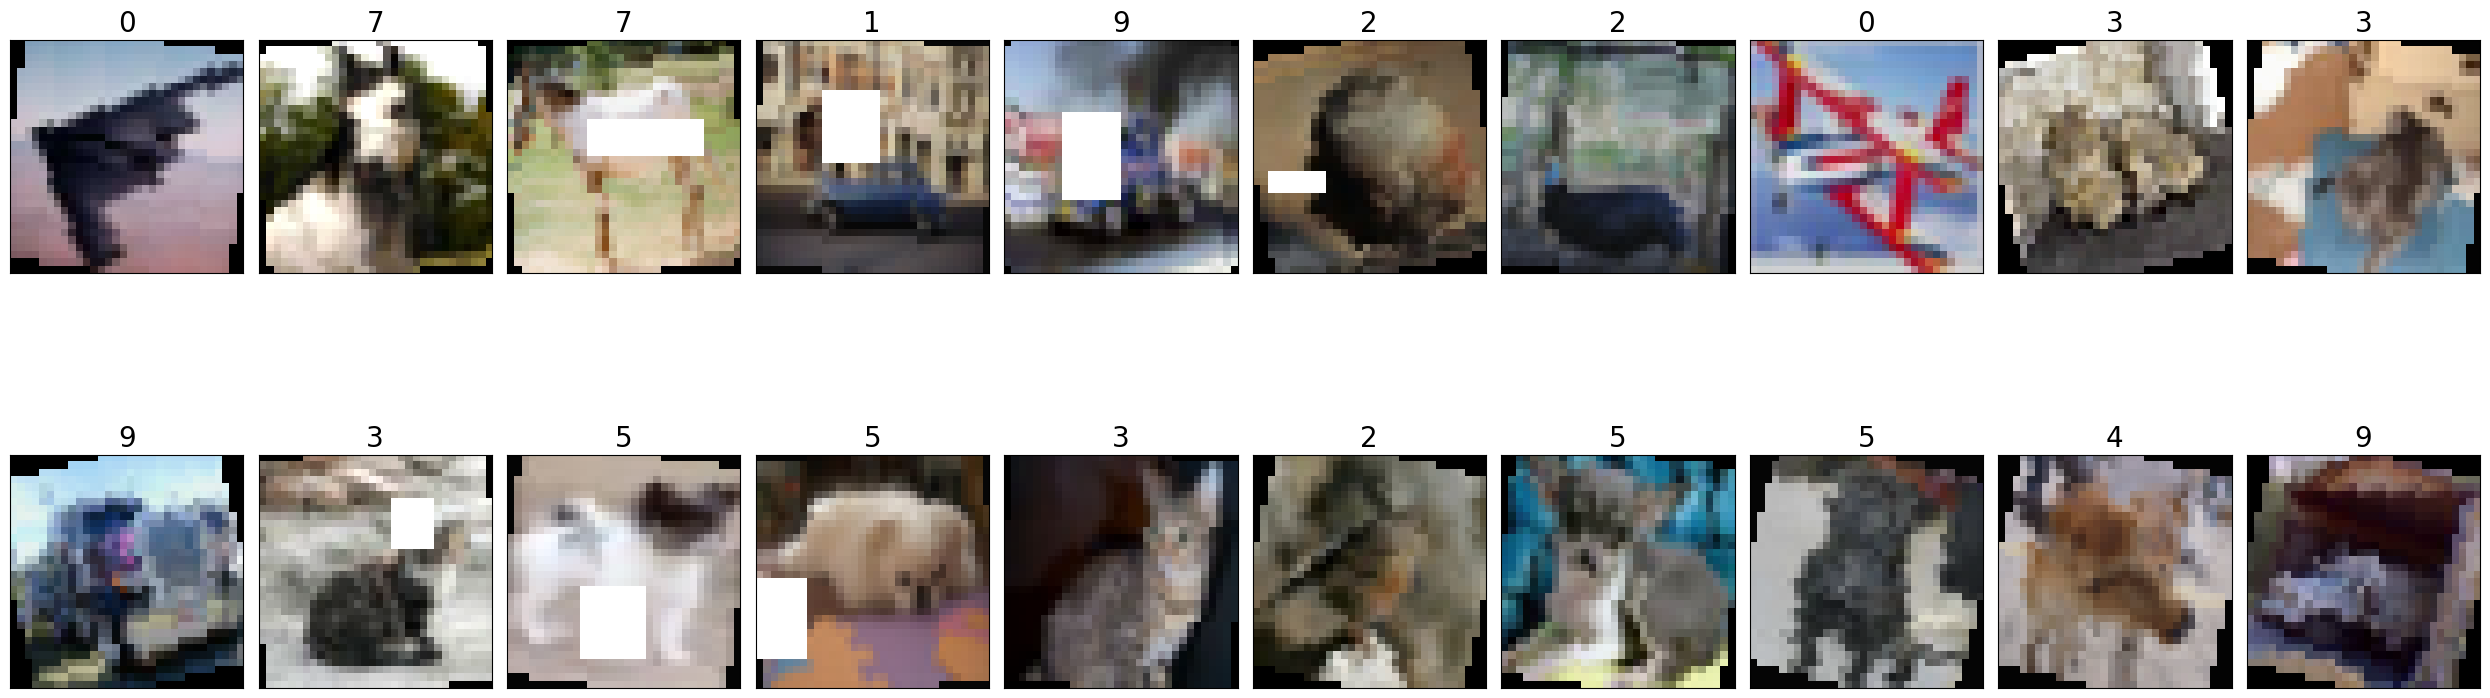

In [5]:
dataiter = iter(loader_train_custom)
images, labels = next(dataiter)
print(type(images))
print(type(labels))

images = images / 2 + 0.5
images = torch.clamp(images, 0, 1)
images = images.numpy()

fig = plt.figure(figsize = (25, 10))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx + 1, xticks = [], yticks = [])
    image = np.transpose(images[idx], (1, 2, 0))
    ax.imshow(image)
    ax.set_title(str(labels[idx].item()), fontsize = 20)

plt.tight_layout()
plt.show()

# Build network

## 1. CNN

In [6]:
def conv3x3(channels_in, channels_out):
    """Tích chập 3x3 giữ nguyên kích thước không gian ảnh (padding=1)."""
    return nn.Conv2d(channels_in, channels_out, kernel_size=3, stride=1, padding=1, bias=False)

def strided_conv_pool(channels_in):
    """Dùng tích chập với stride=2 để giảm một nửa kích thước ảnh."""
    return nn.Conv2d(channels_in, channels_in, kernel_size=2, stride=2, bias=False)

def conv1x1(channels_in, channels_out):
    """Tích chập 1x1 dùng để thay đổi số lượng kênh (channels)."""
    return nn.Conv2d(channels_in, channels_out, kernel_size=1, stride=1)


class PreActConvLayer(nn.Sequential):
    """Lớp Pre-activation: Chuẩn hóa (BatchNorm) -> Kích hoạt (ReLU) -> Tích chập (Conv)"""
    def __init__(self, channels):
        super().__init__(
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=False), 
            conv3x3(channels, channels)
        )

class ResidualBlock(nn.Module):
    """Khối Residual với cơ chế kết nối tắt (skip connections)."""
    def __init__(self, channels, num_layers):
        super().__init__()
        self.layers = nn.ModuleList([PreActConvLayer(channels) for _ in range(num_layers)])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x) + x 
        return x

class TransitionLayer(nn.Sequential):
    """Lớp chuyển tiếp: Đổi số kênh, giảm kích thước ảnh và dùng Dropout."""
    def __init__(self, channels_in, channels_out, dropout_rate=0.1):
        super().__init__(
            nn.BatchNorm2d(channels_in),
            nn.ReLU(inplace=False),
            conv1x1(channels_in, channels_out),
            strided_conv_pool(channels_out),
            nn.Dropout(dropout_rate)
        )

class Stage(nn.Sequential):
    """Gói gọn một giai đoạn gồm khối Residual và khối Chuyển tiếp."""
    def __init__(self, channels_in, channels_out, num_layers):
        super().__init__(
            ResidualBlock(channels_in, num_layers),
            TransitionLayer(channels_in, channels_out)
        )


class CustomResNet(nn.Sequential):
    """Kiến trúc mạng tổng thể được thiết kế riêng cho CIFAR-10."""
    def __init__(self):
        super().__init__(
            Stage(channels_in=3,   channels_out=32,  num_layers=5),  # Output: 32x16x16
            Stage(channels_in=32,  channels_out=64,  num_layers=5),  # Output: 64x8x8
            Stage(channels_in=64,  channels_out=128, num_layers=5),  # Output: 128x4x4
            Stage(channels_in=128, channels_out=64,  num_layers=5),  # Output: 64x2x2
            Stage(channels_in=64,  channels_out=16,  num_layers=5),  # Output: 16x1x1            
            conv1x1(channels_in=16, channels_out=10),                # Output: 10x1x1
            nn.Flatten()                                             # Output: 10
        )

## Custom

In [7]:
LEARNING_RATE = 0.001

custom_model = CustomResNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(custom_model.parameters(), lr=LEARNING_RATE)

# if torch.cuda.device_count() > 1:
#     custom_model = nn.DataParallel(custom_model)

custom_model = custom_model.to(device)

summary(custom_model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                        Output Shape              Param #
CustomResNet                                  [1, 10]                   --
├─Stage: 1-1                                  [1, 32, 16, 16]           --
│    └─ResidualBlock: 2-1                     [1, 3, 32, 32]            --
│    │    └─ModuleList: 3-1                   --                        435
│    └─TransitionLayer: 2-2                   [1, 32, 16, 16]           --
│    │    └─BatchNorm2d: 3-2                  [1, 3, 32, 32]            6
│    │    └─ReLU: 3-3                         [1, 3, 32, 32]            --
│    │    └─Conv2d: 3-4                       [1, 32, 32, 32]           128
│    │    └─Conv2d: 3-5                       [1, 32, 16, 16]           4,096
│    │    └─Dropout: 3-6                      [1, 32, 16, 16]           --
├─Stage: 1-2                                  [1, 64, 8, 8]             --
│    └─ResidualBlock: 2-3                     [1, 32, 16, 16]           --
│    │    └─Modu

# ResNet

In [8]:
resnet18_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet18_model.fc = nn.Linear(resnet18_model.fc.in_features, 10)

if torch.cuda.device_count() > 1:
    resnet18_model = nn.DataParallel(resnet18_model)

resnet18_model = resnet18_model.to(device)
summary(resnet18_model, input_size=(1, 3, 224, 224), device=device.type)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


Layer (type:depth-idx)                        Output Shape              Param #
DataParallel                                  [1, 10]                   --
├─ResNet: 1-1                                 [1, 10]                   11,181,642
├─ResNet: 1-2                                 --                        --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         128
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
│    └─Sequential: 2-5                        [1, 64, 56, 56]           147,968
│    └─Sequential: 2-6                        --                        --
│    │    └─BasicBlock: 3-1                   [1, 64, 56, 56]           73,984
│    │    └─BasicBlock: 3-2                   --                        73,984
│    │    └─BasicBlock: 3-3                   [1, 64, 56, 56]         

In [9]:
import torch.nn as nn
import torchvision.models as models

model_resnet_frozen = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model_resnet_frozen.parameters():
    param.requires_grad = False

in_features = model_resnet_frozen.fc.in_features
model_resnet_frozen.fc = nn.Linear(in_features, 10)

if torch.cuda.device_count() > 1:
    model_resnet_frozen = nn.DataParallel(model_resnet_frozen)

model_resnet_frozen = model_resnet_frozen.to(device)
summary(model_resnet_frozen, input_size=(1, 3, 224, 224), device=device.type)
# print(f"Tham số cần train: {sum(p.numel() for p in model_resnet_frozen.parameters() if p.requires_grad):,}")

Layer (type:depth-idx)                        Output Shape              Param #
DataParallel                                  [1, 10]                   --
├─ResNet: 1-1                                 [1, 10]                   11,181,642
├─ResNet: 1-2                                 --                        --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         (9,408)
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         (128)
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
│    └─Sequential: 2-5                        [1, 64, 56, 56]           147,968
│    └─Sequential: 2-6                        --                        --
│    │    └─BasicBlock: 3-1                   [1, 64, 56, 56]           (73,984)
│    │    └─BasicBlock: 3-2                   --                        (73,984)
│    │    └─BasicBlock: 3-3                   [1, 64, 56, 56] 

## ViT

In [10]:
import torch
import torch.nn as nn
import torchvision.models as models

vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

for param in vit_model.parameters():
    param.requires_grad = False

in_features = vit_model.heads.head.in_features
vit_model.heads.head = nn.Linear(in_features, 10)

if torch.cuda.device_count() > 1:
    vit_model = nn.DataParallel(vit_model)

vit_model = vit_model.to(device)
summary(vit_model, input_size=(1, 3, 224, 224), device=device.type)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 204MB/s]


Layer (type:depth-idx)                             Output Shape              Param #
DataParallel                                       [1, 10]                   --
├─VisionTransformer: 1-1                           [1, 10]                   85,806,346
├─VisionTransformer: 1-2                           --                        --
│    └─Conv2d: 2-1                                 [1, 768, 14, 14]          (590,592)
│    └─Encoder: 2-2                                [1, 197, 768]             85,207,296
│    └─Encoder: 2-3                                --                        --
│    │    └─Dropout: 3-1                           [1, 197, 768]             --
│    │    └─Sequential: 3-2                        [1, 197, 768]             (85,054,464)
│    │    └─Sequential: 3-3                        --                        (85,054,464)
│    │    └─LayerNorm: 3-4                         [1, 197, 768]             (1,536)
│    └─Sequential: 2-4                             [1, 10]         

In [11]:
def train_and_evaluate(model_name, model, train_loader, val_loader, epochs, lr, device, patience=5, save_path=None):
    print(f"\nTraining Model {model_name.upper()}")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # mode='min': Theo dõi val_loss (càng nhỏ càng tốt)
    # factor=0.5: Giảm LR đi một nửa (chia 2) mỗi lần kích hoạt
    # patience=2: Waiting 2 epochs, if loss not down, decre LR
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    if save_path is None:
        save_name = model_name.replace(" ", "_").lower()
        save_path = f"best_model_{save_name}.pth"
    
    for epoch in range(epochs):
        current_lr = optimizer.param_groups[0]['lr']
        print(f"\nEpoch [{epoch+1}/{epochs}] | Current LR: {current_lr:.6f}")
        
        # --- TRAIN ---
        model.train()
        running_train_loss = 0.0
        correct_train, total_train = 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            
        train_loss = running_train_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        
        model.eval()
        running_val_loss = 0.0
        correct_val, total_val = 0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                running_val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                
        val_loss = running_val_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"   ↳ Train Loss: {train_loss:.4f} - Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} - Acc: {val_acc:.2f}%")
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"Save current best checkpoint")
        else:
            epochs_no_improve += 1
            print(f"Alert: Val Loss keeping ({epochs_no_improve}/{patience})")
            
            if epochs_no_improve >= patience:
                print(f"\nEARLY STOPPING! Stop at Epoch {epoch+1}.")
                break
                
    if os.path.exists(save_path):
        print(f"\nLoad model state from '{save_path}'...")
        model.load_state_dict(torch.load(save_path, map_location=device))
        
    return history

In [12]:
EPOCHSCustomResNet = 50
history_custom = train_and_evaluate(
    "Custom ResNet", custom_model, 
    loader_train_custom, loader_val_custom,
    EPOCHSCustomResNet, lr=0.001, device=device, patience=5
)


Training Model CUSTOM RESNET

Epoch [1/50] | Current LR: 0.001000
   ↳ Train Loss: 1.9238 - Acc: 27.81% | Val Loss: 1.9518 - Acc: 30.41%
Save current best checkpoint

Epoch [2/50] | Current LR: 0.001000
   ↳ Train Loss: 1.5876 - Acc: 41.01% | Val Loss: 1.5717 - Acc: 43.24%
Save current best checkpoint

Epoch [3/50] | Current LR: 0.001000
   ↳ Train Loss: 1.4285 - Acc: 47.74% | Val Loss: 1.4370 - Acc: 48.07%
Save current best checkpoint

Epoch [4/50] | Current LR: 0.001000
   ↳ Train Loss: 1.3294 - Acc: 51.94% | Val Loss: 1.3141 - Acc: 52.46%
Save current best checkpoint

Epoch [5/50] | Current LR: 0.001000
   ↳ Train Loss: 1.2525 - Acc: 54.46% | Val Loss: 1.2820 - Acc: 54.24%
Save current best checkpoint

Epoch [6/50] | Current LR: 0.001000
   ↳ Train Loss: 1.1669 - Acc: 58.23% | Val Loss: 1.2366 - Acc: 56.70%
Save current best checkpoint

Epoch [7/50] | Current LR: 0.001000
   ↳ Train Loss: 1.1061 - Acc: 60.45% | Val Loss: 1.1947 - Acc: 58.20%
Save current best checkpoint

Epoch [8/5

In [13]:
# Pre-trained ResNet18
EPOCHS_NesNet = 40
history_pre = train_and_evaluate(
    "Pre-trained ResNet18", resnet18_model, 
    loader_train_pre, loader_val_pre,
    EPOCHS_NesNet, lr=0.0001, device=device, patience=5
)


Training Model PRE-TRAINED RESNET18

Epoch [1/40] | Current LR: 0.000100
   ↳ Train Loss: 0.7129 - Acc: 76.46% | Val Loss: 0.3372 - Acc: 88.97%
Save current best checkpoint

Epoch [2/40] | Current LR: 0.000100
   ↳ Train Loss: 0.2762 - Acc: 90.79% | Val Loss: 0.2654 - Acc: 90.93%
Save current best checkpoint

Epoch [3/40] | Current LR: 0.000100
   ↳ Train Loss: 0.2027 - Acc: 93.13% | Val Loss: 0.2298 - Acc: 92.02%
Save current best checkpoint

Epoch [4/40] | Current LR: 0.000100
   ↳ Train Loss: 0.1594 - Acc: 94.81% | Val Loss: 0.1993 - Acc: 93.06%
Save current best checkpoint

Epoch [5/40] | Current LR: 0.000100
   ↳ Train Loss: 0.1276 - Acc: 95.82% | Val Loss: 0.1950 - Acc: 93.33%
Save current best checkpoint

Epoch [6/40] | Current LR: 0.000100
   ↳ Train Loss: 0.1099 - Acc: 96.36% | Val Loss: 0.1798 - Acc: 94.05%
Save current best checkpoint

Epoch [7/40] | Current LR: 0.000100
   ↳ Train Loss: 0.0914 - Acc: 97.11% | Val Loss: 0.1892 - Acc: 93.55%
Alert: Val Loss keeping (1/5)

Ep

In [14]:
# Pre-trained ResNet18
EPOCHS_NesNetFronze = 40
history_model_resnet_frozen = train_and_evaluate(
    "Pre-trained ResNet18 Fronzen", model_resnet_frozen, 
    loader_train_pre, loader_val_pre,
    EPOCHS_NesNetFronze, lr=0.0001, device=device, patience=5
)


Training Model PRE-TRAINED RESNET18 FRONZEN

Epoch [1/40] | Current LR: 0.000100
   ↳ Train Loss: 2.1704 - Acc: 21.52% | Val Loss: 2.0204 - Acc: 32.51%
Save current best checkpoint

Epoch [2/40] | Current LR: 0.000100
   ↳ Train Loss: 1.8992 - Acc: 38.99% | Val Loss: 1.7878 - Acc: 44.65%
Save current best checkpoint

Epoch [3/40] | Current LR: 0.000100
   ↳ Train Loss: 1.7051 - Acc: 48.81% | Val Loss: 1.6179 - Acc: 52.38%
Save current best checkpoint

Epoch [4/40] | Current LR: 0.000100
   ↳ Train Loss: 1.5598 - Acc: 54.51% | Val Loss: 1.4801 - Acc: 57.40%
Save current best checkpoint

Epoch [5/40] | Current LR: 0.000100
   ↳ Train Loss: 1.4519 - Acc: 57.91% | Val Loss: 1.3919 - Acc: 59.59%
Save current best checkpoint

Epoch [6/40] | Current LR: 0.000100
   ↳ Train Loss: 1.3640 - Acc: 60.27% | Val Loss: 1.3159 - Acc: 61.59%
Save current best checkpoint

Epoch [7/40] | Current LR: 0.000100
   ↳ Train Loss: 1.2979 - Acc: 61.42% | Val Loss: 1.2593 - Acc: 63.47%
Save current best checkpo

In [15]:
EPOCHSViT = 20
history_vit = train_and_evaluate(
    "Pre-trained ViT", vit_model, 
    loader_train_pre, loader_val_pre,
    EPOCHSViT, lr=0.00005, device=device, patience=5
)


Training Model PRE-TRAINED VIT

Epoch [1/20] | Current LR: 0.000050
   ↳ Train Loss: 2.0673 - Acc: 30.18% | Val Loss: 1.8002 - Acc: 54.19%
Save current best checkpoint

Epoch [2/20] | Current LR: 0.000050
   ↳ Train Loss: 1.5824 - Acc: 67.78% | Val Loss: 1.3848 - Acc: 77.49%
Save current best checkpoint

Epoch [3/20] | Current LR: 0.000050
   ↳ Train Loss: 1.2252 - Acc: 81.27% | Val Loss: 1.0859 - Acc: 84.19%
Save current best checkpoint

Epoch [4/20] | Current LR: 0.000050
   ↳ Train Loss: 0.9761 - Acc: 85.67% | Val Loss: 0.8844 - Acc: 86.89%
Save current best checkpoint

Epoch [5/20] | Current LR: 0.000050
   ↳ Train Loss: 0.8071 - Acc: 87.41% | Val Loss: 0.7461 - Acc: 87.94%
Save current best checkpoint

Epoch [6/20] | Current LR: 0.000050
   ↳ Train Loss: 0.6910 - Acc: 88.46% | Val Loss: 0.6452 - Acc: 89.24%
Save current best checkpoint

Epoch [7/20] | Current LR: 0.000050
   ↳ Train Loss: 0.6090 - Acc: 89.01% | Val Loss: 0.5765 - Acc: 89.13%
Save current best checkpoint

Epoch [8

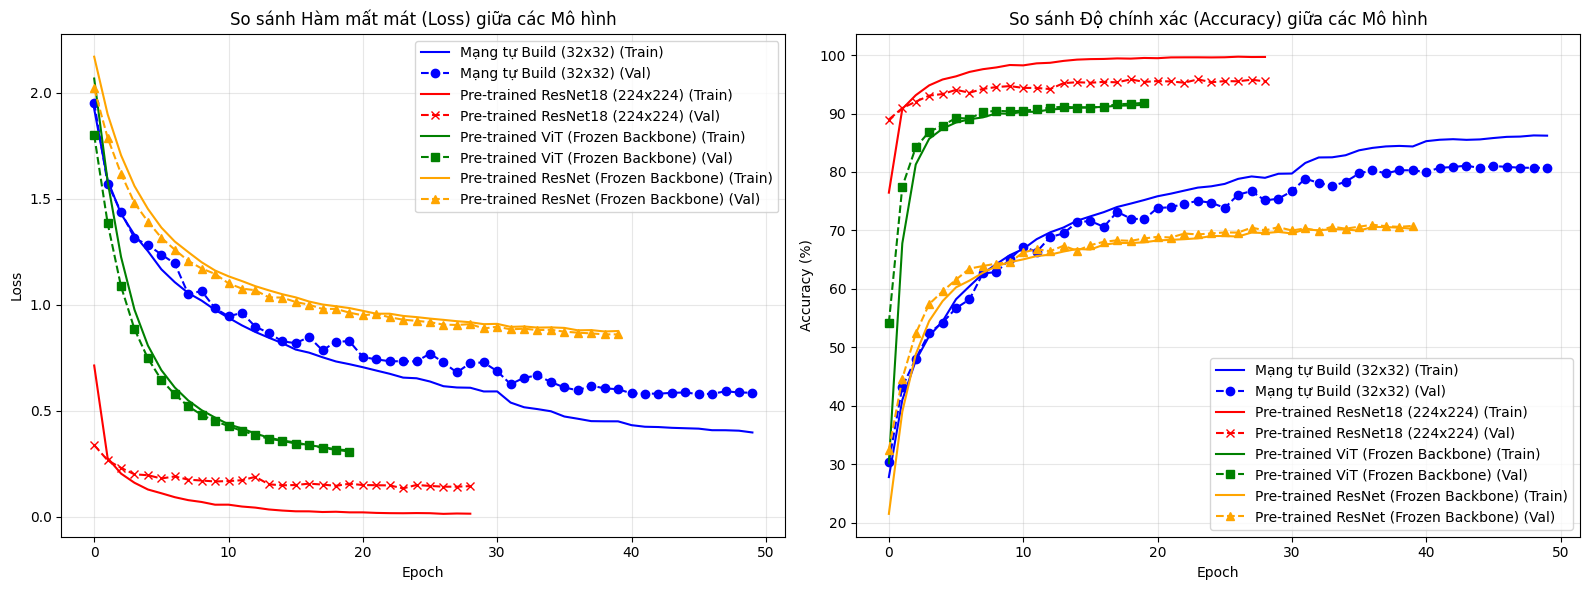

In [16]:
import matplotlib.pyplot as plt

def plot_models_comparison(histories_dict):
    """
    histories_dict: dict chứa tên mô hình (key) và lịch sử huấn luyện (value).
    Ví dụ: 
    {
        "Mạng A": {'train_loss': [...], 'val_loss': [...], ...},
        "Mạng B": {'train_loss': [...], 'val_loss': [...], ...}
    }
    """
    if not histories_dict:
        print("Cảnh báo: Không có dữ liệu để vẽ!")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'teal']
    markers = ['o', 'x', 's', '^', 'D', 'v', '*']
    
    for i, (name, hist) in enumerate(histories_dict.items()):
        c = colors[i % len(colors)]
        m = markers[i % len(markers)]
        
        axes[0].plot(hist['train_loss'], label=f'{name} (Train)', color=c, linestyle='-')
        axes[0].plot(hist['val_loss'],   label=f'{name} (Val)',   color=c, linestyle='--', marker=m)
        
        axes[1].plot(hist['train_acc'], label=f'{name} (Train)', color=c, linestyle='-')
        axes[1].plot(hist['val_acc'],   label=f'{name} (Val)',   color=c, linestyle='--', marker=m)
    
    axes[0].set_title('So sánh Hàm mất mát (Loss) giữa các Mô hình')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    axes[1].set_title('So sánh Độ chính xác (Accuracy) giữa các Mô hình')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

my_models_data = {
    "Mạng tự Build (32x32)": history_custom,
    "Pre-trained ResNet18 (224x224)": history_pre,
    "Pre-trained ViT (Frozen Backbone)": history_vit,
    "Pre-trained ResNet (Frozen Backbone)": history_model_resnet_frozen
}

plot_models_comparison(my_models_data)

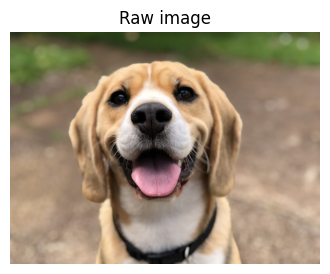

                                Result                                
🔹 Custom ResNet (32x32)          | Prediction: Chó (Dog)       | Confidence:  96.73%
🔹 Pre-trained ResNet18           | Prediction: Chó (Dog)       | Confidence:  99.78%
🔹 Pre-trained ResNet18 Fronze    | Prediction: Chó (Dog)       | Confidence:  89.81%
🔹 Pre-trained ViT (Frozen)       | Prediction: Chó (Dog)       | Confidence:  66.71%


In [17]:
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

cifar10_classes = ['Máy bay (Plane)', 'Ô tô (Car)', 'Chim (Bird)', 'Mèo (Cat)', 
                   'Hươu (Deer)', 'Chó (Dog)', 'Ếch (Frog)', 'Ngựa (Horse)', 
                   'Tàu thủy (Ship)', 'Xe tải (Truck)']

transform_custom = transforms.Compose([
    transforms.Resize((32, 32)), 
    transforms.ToTensor(),       
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
transform_pretrained = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

def compare_internet_image_scalable(url, models_dict, device):
    """
    url: Link ảnh
    models_dict: Dict chứa tên mô hình làm Key, Value là 1 tuple (model, transform)
    """
    try:
        response = requests.get(url)
        img = Image.open(BytesIO(response.content)).convert('RGB')
    except Exception as e:
        print("Err download image")
        return
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Raw image")
    plt.show()

    print("=" * 70)
    print("Result".center(70))
    print("=" * 70)

    for name, (model, transform) in models_dict.items():
        tensor_img = transform(img).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad():
            output = model(tensor_img)
            prob = F.softmax(output, dim=1)
            conf, idx = torch.max(prob, 1)
            
            predicted_label = cifar10_classes[idx.item()]
            confidence = conf.item() * 100
            
        print(f"🔹 {name:<30} | Prediction: {predicted_label:<15} | Confidence: {confidence:>6.2f}%")
        
    print("=" * 70)

my_inference_models = {
    "Custom ResNet (32x32)":       (custom_model, transform_custom),
    "Pre-trained ResNet18":        (resnet18_model, transform_pretrained),
    "Pre-trained ResNet18 Fronze":        (model_resnet_frozen, transform_pretrained),
    "Pre-trained ViT (Frozen)":  (vit_model, transform_pretrained)
}

test_url = "https://images.unsplash.com/photo-1543466835-00a7907e9de1?q=80&w=600&auto=format&fit=crop"

compare_internet_image_scalable(test_url, my_inference_models, device)

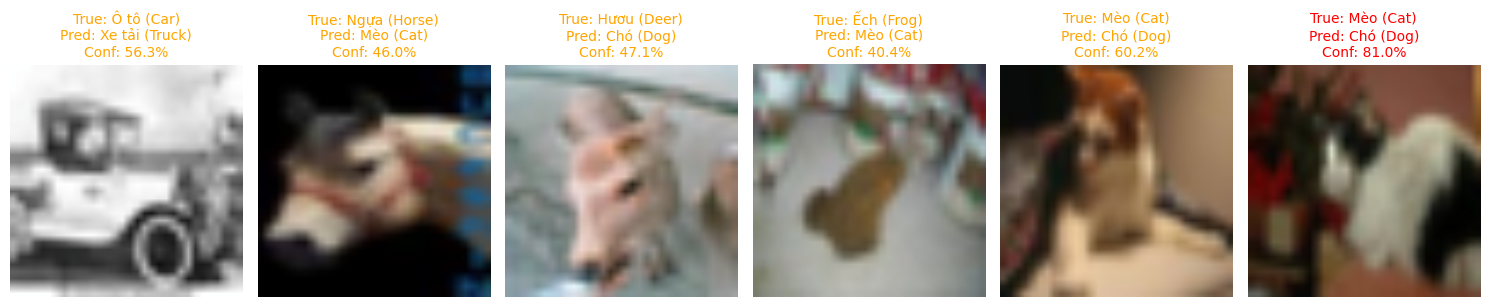

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def analyze_misclassified_images(model, test_loader, device, classes, num_images=5):
    """Tìm và hiển thị những ảnh mà mô hình đoán sai"""
    model.eval()
    misclassified = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            
            probs = torch.nn.functional.softmax(outputs, dim=1)
            confidences, preds = torch.max(probs, 1)
            
            # Tìm các vị trí đoán sai
            wrong_idx = (preds != labels).nonzero(as_tuple=True)[0]
            
            for idx in wrong_idx:
                misclassified.append({
                    'image': inputs[idx].cpu(),
                    'true_label': classes[labels[idx].item()],
                    'pred_label': classes[preds[idx].item()],
                    'confidence': confidences[idx].item() * 100
                })
                
            if len(misclassified) >= num_images:
                break
                
    # Vẽ hình lên báo cáo
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    for i in range(num_images):
        item = misclassified[i]
        # Bỏ chuẩn hóa để hiển thị ảnh cho đúng màu
        img = item['image'].numpy().transpose((1, 2, 0))
        mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f"True: {item['true_label']}\nPred: {item['pred_label']}\nConf: {item['confidence']:.1f}%", 
                          color='red' if item['confidence'] > 80 else 'orange', fontsize=10)
    plt.tight_layout()
    plt.show()

analyze_misclassified_images(vit_model, loader_test_pre, device, cifar10_classes, num_images=6)

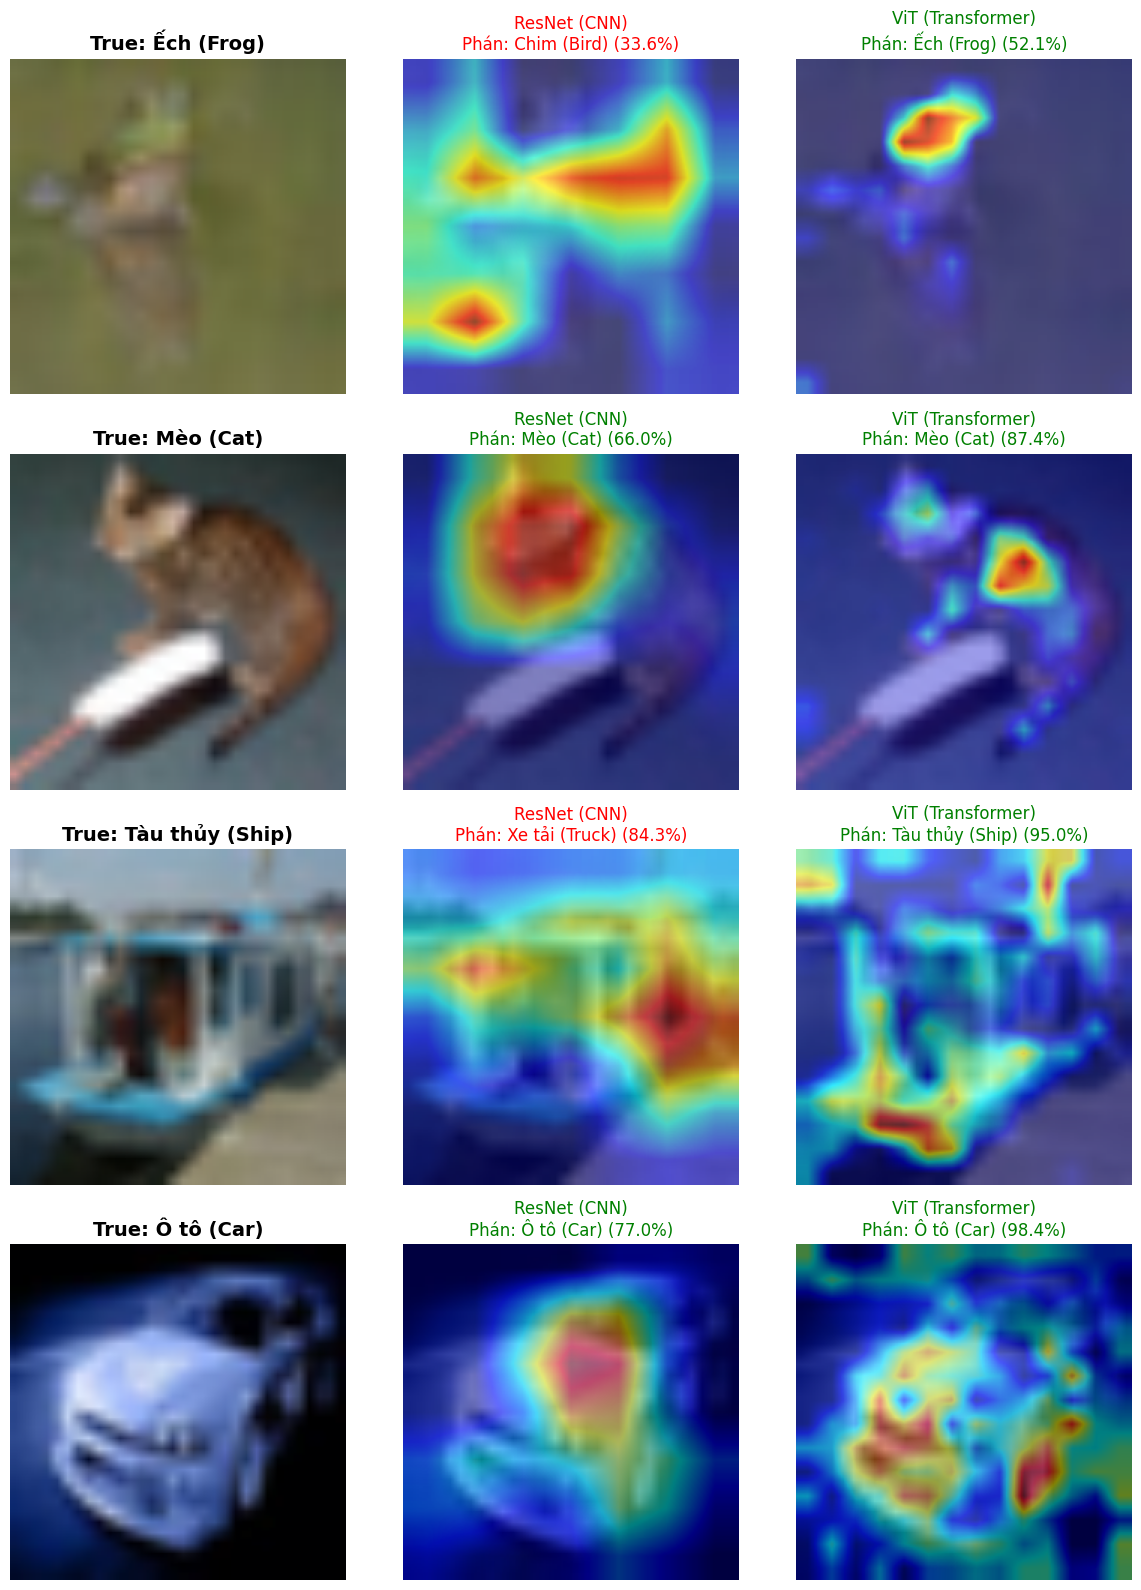

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image


def reshape_transform_vit(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

def compare_4_test_images(model_res, vit_model, test_loader, device, classes):
    # --- Khởi tạo 2 đối tượng CAM riêng biệt ---
    
    # 1. ResNet: Lấy mô hình gốc và nhìn lớp layer4[-1]
    core_model_res = model_res.module if hasattr(model_res, 'module') else model_res
    target_layer_res = [core_model_res.layer4[-1]]
    for p in target_layer_res[0].parameters(): 
        p.requires_grad = True # 🔓
    model_res.eval()
    cam_res = GradCAM(model=model_res, target_layers=target_layer_res)

    # 2. ViT: Lấy mô hình gốc và nhìn lớp encoder.layers[-1].ln_1 + Reshape Transform
    core_vit_model = vit_model.module if hasattr(vit_model, 'module') else vit_model
    target_layer_vit = [core_vit_model.encoder.layers[-1].ln_1]
    for p in target_layer_vit[0].parameters(): 
        p.requires_grad = True # 🔓
    vit_model.eval()
    cam_vit = GradCAM(model=vit_model, target_layers=target_layer_vit, reshape_transform=reshape_transform_vit)

    for inputs, labels in test_loader:
        batch_size = inputs.size(0)
        num_samples = min(4, batch_size) 
        indices = random.sample(range(batch_size), num_samples)
        
        input_tensors = inputs[indices].to(device)
        true_labels = labels[indices]
        break

    # 4 dòng: Mỗi dòng 1 ảnh. 3 cột: Ảnh Gốc, ResNet, ViT
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 16))
    
    for i in range(num_samples):
        input_tensor = input_tensors[i:i+1] # Lấy ảnh thứ i, dạng [1, 3, 224, 224]
        img_show = input_tensor.squeeze(0).cpu().numpy().transpose((1, 2, 0))
        
        mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
        img_show = std * img_show + mean
        img_show = np.clip(img_show, 0, 1) # Ép về 0 -> 1

        axes[i, 0].imshow(img_show)
        axes[i, 0].set_title(f"True: {classes[true_labels[i].item()]}", fontsize=14, fontweight='bold')
        axes[i, 0].axis('off')

        # --- 2. Xử lý ResNet ---
        with torch.no_grad():
            # Dự đoán
            out_res = model_res(input_tensor)
            prob_res = torch.nn.functional.softmax(out_res, dim=1)[0]
            conf_res, idx_res = torch.max(prob_res, 0)
        
        # Grad-CAM cho ResNet
        grayscale_cam_res = cam_res(input_tensor=input_tensor, targets=None)[0, :]
        cam_image_res = show_cam_on_image(img_show, grayscale_cam_res, use_rgb=True)
        
        # Cột 2: ResNet Grad-CAM
        axes[i, 1].imshow(cam_image_res)
        res_color = 'green' if idx_res == true_labels[i] else 'red'
        axes[i, 1].set_title(f"ResNet (CNN)\nPhán: {classes[idx_res.item()]} ({conf_res.item()*100:.1f}%)", color=res_color)
        axes[i, 1].axis('off')

        with torch.no_grad():
            out_vit = vit_model(input_tensor)
            prob_vit = torch.nn.functional.softmax(out_vit, dim=1)[0]
            conf_vit, idx_vit = torch.max(prob_vit, 0)
    
        grayscale_cam_vit = cam_vit(input_tensor=input_tensor, targets=None)[0, :]
        cam_image_vit = show_cam_on_image(img_show, grayscale_cam_vit, use_rgb=True)
        
        axes[i, 2].imshow(cam_image_vit)
        vit_color = 'green' if idx_vit == true_labels[i] else 'red'
        axes[i, 2].set_title(f"ViT (Transformer)\nPhán: {classes[idx_vit.item()]} ({conf_vit.item()*100:.1f}%)", color=vit_color)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

compare_4_test_images(
    model_resnet_frozen, 
    vit_model, 
    loader_test_pre,
    device, 
    cifar10_classes
)

Testing Pre-trained resnet18...


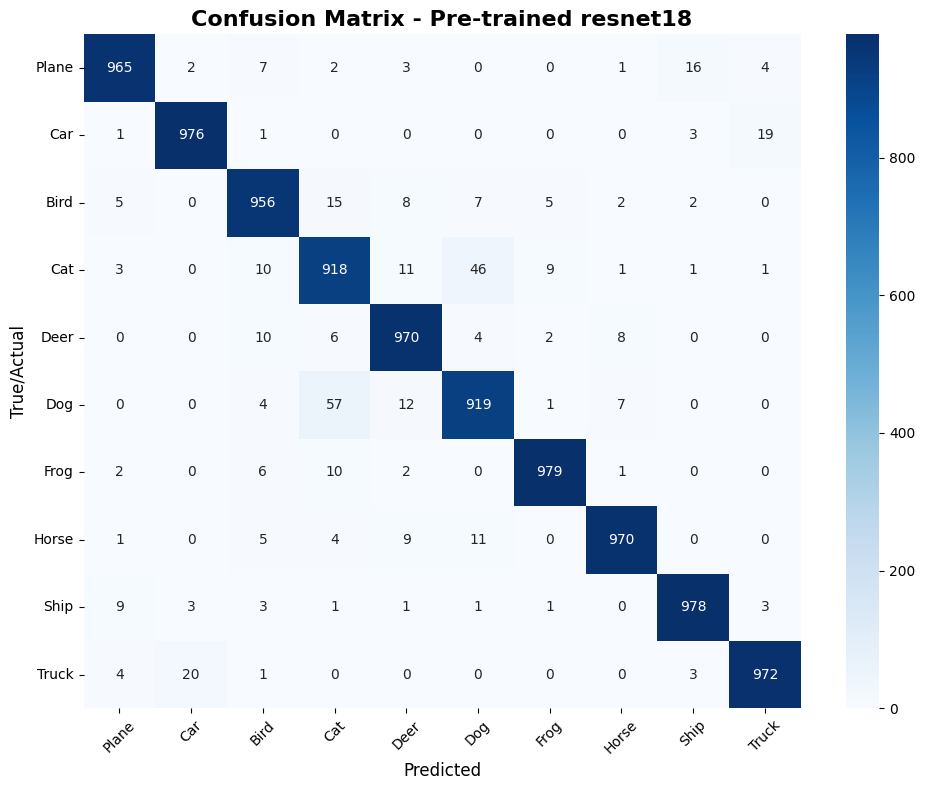

        CLASSIFICATION REPORT: Pre-trained resnet18         
              precision    recall  f1-score   support

       Plane       0.97      0.96      0.97      1000
         Car       0.98      0.98      0.98      1000
        Bird       0.95      0.96      0.95      1000
         Cat       0.91      0.92      0.91      1000
        Deer       0.95      0.97      0.96      1000
         Dog       0.93      0.92      0.92      1000
        Frog       0.98      0.98      0.98      1000
       Horse       0.98      0.97      0.97      1000
        Ship       0.98      0.98      0.98      1000
       Truck       0.97      0.97      0.97      1000

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000

Testing Pre-trained resnet18 fronze...


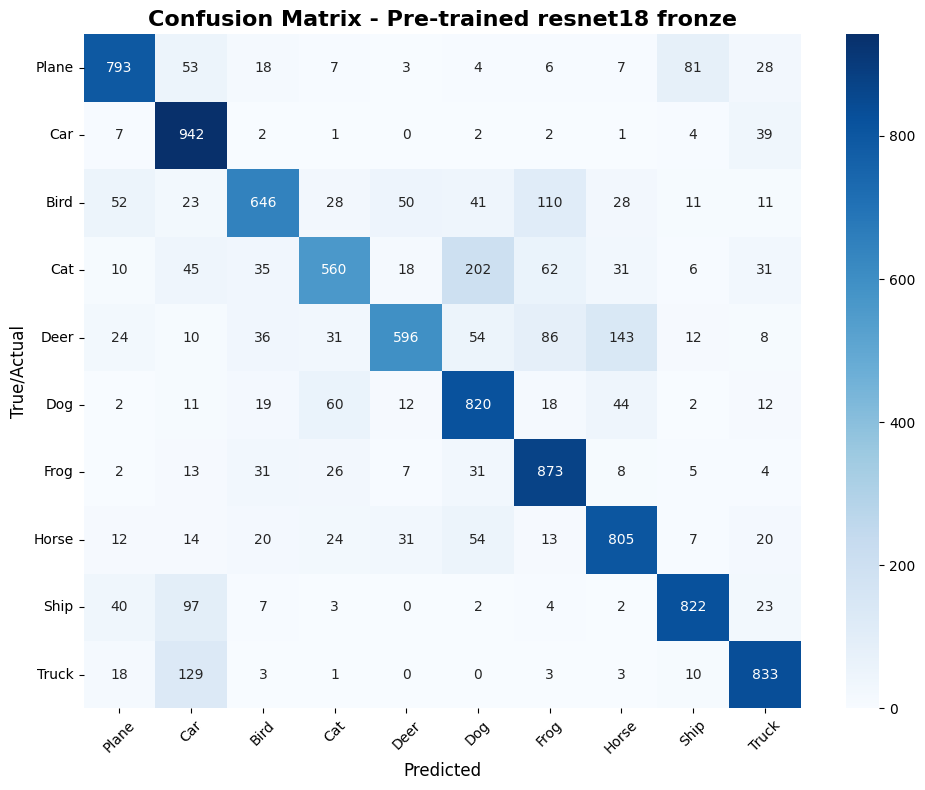

     CLASSIFICATION REPORT: Pre-trained resnet18 fronze     
              precision    recall  f1-score   support

       Plane       0.83      0.79      0.81      1000
         Car       0.70      0.94      0.81      1000
        Bird       0.79      0.65      0.71      1000
         Cat       0.76      0.56      0.64      1000
        Deer       0.83      0.60      0.69      1000
         Dog       0.68      0.82      0.74      1000
        Frog       0.74      0.87      0.80      1000
       Horse       0.75      0.81      0.78      1000
        Ship       0.86      0.82      0.84      1000
       Truck       0.83      0.83      0.83      1000

    accuracy                           0.77     10000
   macro avg       0.78      0.77      0.77     10000
weighted avg       0.78      0.77      0.77     10000

Testing Pre-trained VIT...


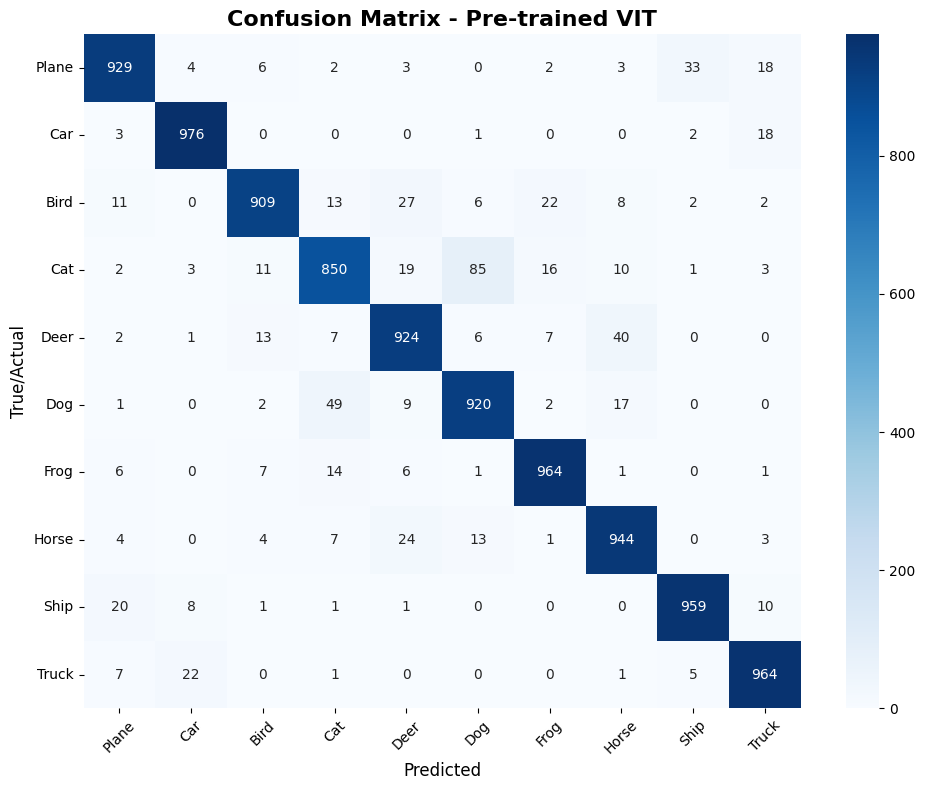

           CLASSIFICATION REPORT: Pre-trained VIT           
              precision    recall  f1-score   support

       Plane       0.94      0.93      0.94      1000
         Car       0.96      0.98      0.97      1000
        Bird       0.95      0.91      0.93      1000
         Cat       0.90      0.85      0.87      1000
        Deer       0.91      0.92      0.92      1000
         Dog       0.89      0.92      0.91      1000
        Frog       0.95      0.96      0.96      1000
       Horse       0.92      0.94      0.93      1000
        Ship       0.96      0.96      0.96      1000
       Truck       0.95      0.96      0.95      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

Testing Custom ResNet 32x32...


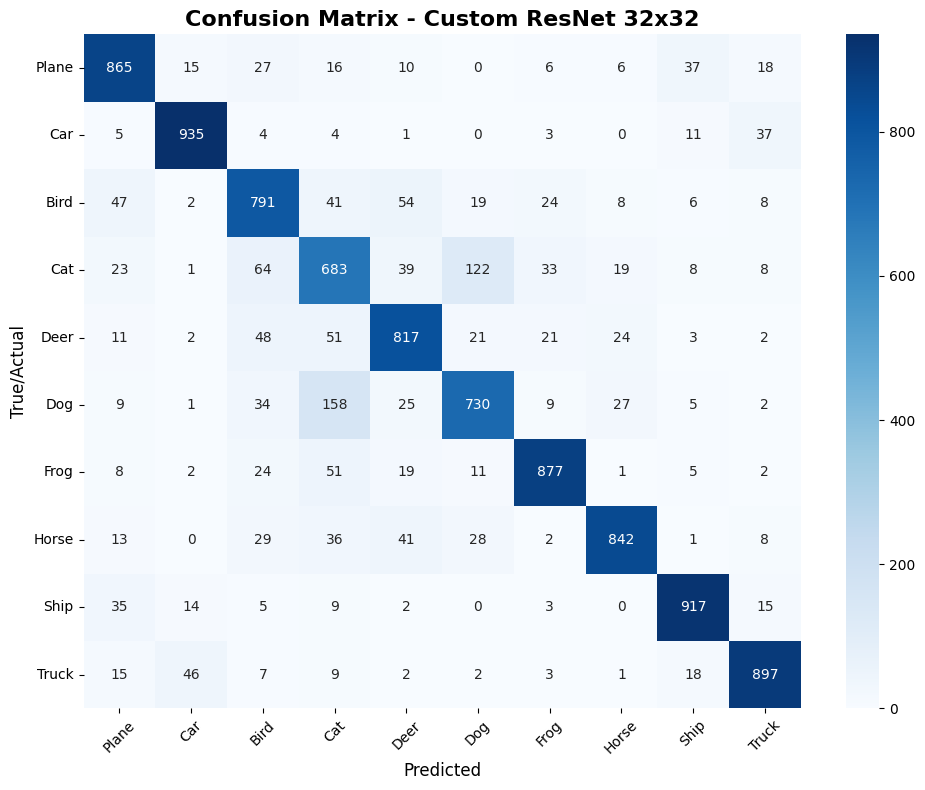

         CLASSIFICATION REPORT: Custom ResNet 32x32         
              precision    recall  f1-score   support

       Plane       0.84      0.86      0.85      1000
         Car       0.92      0.94      0.93      1000
        Bird       0.77      0.79      0.78      1000
         Cat       0.65      0.68      0.66      1000
        Deer       0.81      0.82      0.81      1000
         Dog       0.78      0.73      0.76      1000
        Frog       0.89      0.88      0.89      1000
       Horse       0.91      0.84      0.87      1000
        Ship       0.91      0.92      0.91      1000
       Truck       0.90      0.90      0.90      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cifar10_classes = ['Plane', 'Car', 'Bird', 'Cat', 'Deer', 
                   'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

def plot_confusion_matrix_and_report(model, test_loader, device, model_name="Model"):
    """
    Hàm này sẽ chạy mô hình trên toàn bộ tập test_loader, 
    thu thập dự đoán và vẽ Ma trận nhầm lẫn + Báo cáo chi tiết.
    """
    print(f"Testing {model_name}...")
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=cifar10_classes, 
                yticklabels=cifar10_classes)
    
    plt.title(f'Confusion Matrix - {model_name}', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('True/Actual', fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    print("=" * 60)
    print(f"CLASSIFICATION REPORT: {model_name}".center(60))
    print("=" * 60)
    report = classification_report(all_labels, all_preds, target_names=cifar10_classes)
    print(report)

plot_confusion_matrix_and_report(resnet18_model, loader_test_pre, device, model_name="Pre-trained resnet18")
plot_confusion_matrix_and_report(model_resnet_frozen, loader_test_pre, device, model_name="Pre-trained resnet18 fronze")
plot_confusion_matrix_and_report(vit_model, loader_test_pre, device, model_name="Pre-trained VIT")
plot_confusion_matrix_and_report(custom_model, loader_test_custom, device, model_name="Custom ResNet 32x32")